<a href="https://colab.research.google.com/github/Kiattisak-Prathom/Phuket-Landslide/blob/main/Heatmap_Phuket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1 = pd.read_excel("Nolandslidepointwith12Factors.xls")
df2 = pd.read_excel("landslidepointwith12Factors.xls")

In [ ]:
dfR=pd.concat([df1,df2],axis=0,ignore_index=True)
dfR1=dfR.dropna()
dfR1=dfR1.reset_index(drop=True)

In [ ]:
dfR1

,x,y,mosaic_phuket_Clip,Slope_mosaic1,Aspect_mosai1,Curvatu_mosa1,ndvi_phuket_Clip,ndwi_phuket,Distance_to_Fault,Distance_to_roads,Distance_to_Rivers,Kriging_rain1,TWI_phuket,DMR_Geology,yi
0,423660.4427,903348.7826,17.0,2.510501,68.198593,-0.212121,0.369317,-0.348617,9604.358398,510.881592,192.093735,395.075653,-3.993245,5.0,-1
1,423363.3493,904982.7961,8.0,0.466477,0.000000,-0.106060,0.305938,-0.296988,11274.772461,692.603760,247.386337,365.940582,-3.408210,4.0,-1
2,422249.2492,903497.3293,13.0,1.189142,78.690071,0.000000,0.324387,-0.326209,10012.317383,339.411255,60.000000,381.444000,-4.344110,4.0,-1
3,424997.3628,902606.0492,36.0,4.712167,302.905243,0.000000,0.381087,-0.344792,8822.500000,721.248901,169.705627,409.826752,-5.029994,2.0,-1
4,423140.5293,900229.3024,16.0,1.648825,8.130102,0.106060,0.271951,-0.283007,6621.238770,394.588379,108.166542,428.855164,-4.671074,4.0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,432633.0000,863208.0000,32.0,21.049906,66.960564,0.318181,0.409555,-0.376506,4991.372559,1176.137695,218.403290,328.771881,-5.654658,2.0,1
276,432563.0000,863217.0000,48.0,16.552008,53.914928,-0.318181,0.415610,-0.382663,4936.800781,1231.462524,234.307495,329.278015,-6.312469,2.0,1
277,431034.0000,861296.0000,81.0,32.634781,22.815987,1.166665,0.449365,-0.409443,6010.565918,3491.618652,180.000000,325.960358,-7.773272,2.0,1
278,423754.0000,861833.0000,66.0,15.678538,19.486130,0.530302,0.385574,-0.358184,6643.831543,30.000000,30.000000,298.901520,-6.948433,1.0,1


In [ ]:
Dfr3 = dfR1.drop(columns=['x','y','DMR_Geology','yi'])
display(Dfr3.head())

,mosaic_phuket_Clip,Slope_mosaic1,Aspect_mosai1,Curvatu_mosa1,ndvi_phuket_Clip,ndwi_phuket,Distance_to_Fault,Distance_to_roads,Distance_to_Rivers,Kriging_rain1,TWI_phuket
0,17.0,2.510501,68.198593,-0.212121,0.369317,-0.348617,9604.358398,510.881592,192.093735,395.075653,-3.993245
1,8.0,0.466477,0.000000,-0.106060,0.305938,-0.296988,11274.772461,692.603760,247.386337,365.940582,-3.408210
2,13.0,1.189142,78.690071,0.000000,0.324387,-0.326209,10012.317383,339.411255,60.000000,381.444000,-4.344110
3,36.0,4.712167,302.905243,0.000000,0.381087,-0.344792,8822.500000,721.248901,169.705627,409.826752,-5.029994
4,16.0,1.648825,8.130102,0.106060,0.271951,-0.283007,6621.238770,394.588379,108.166542,428.855164,-4.671074


In [ ]:
new_column_names = {col: f'F{i+1}' for i, col in enumerate(Dfr3.columns)}
Dfr3 = Dfr3.rename(columns=new_column_names)
display(Dfr3.head())

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
0,17.0,2.510501,68.198593,-0.212121,0.369317,-0.348617,9604.358398,510.881592,192.093735,395.075653,-3.993245
1,8.0,0.466477,0.000000,-0.106060,0.305938,-0.296988,11274.772461,692.603760,247.386337,365.940582,-3.408210
2,13.0,1.189142,78.690071,0.000000,0.324387,-0.326209,10012.317383,339.411255,60.000000,381.444000,-4.344110
3,36.0,4.712167,302.905243,0.000000,0.381087,-0.344792,8822.500000,721.248901,169.705627,409.826752,-5.029994
4,16.0,1.648825,8.130102,0.106060,0.271951,-0.283007,6621.238770,394.588379,108.166542,428.855164,-4.671074


In [ ]:
Dfr3.to_csv('Dfr3.csv', index=False)

           F1        F2        F3        F4        F5        F6        F7  \
F1   1.000000  0.726582  0.070018 -0.007882  0.409170 -0.409391 -0.055276   
F2   0.726582  1.000000  0.096733 -0.135004  0.423099 -0.427618  0.093725   
F3   0.070018  0.096733  1.000000 -0.086329 -0.056915  0.086779 -0.067077   
F4  -0.007882 -0.135004 -0.086329  1.000000 -0.006847  0.000674 -0.040321   
F5   0.409170  0.423099 -0.056915 -0.006847  1.000000 -0.984033  0.114257   
F6  -0.409391 -0.427618  0.086779  0.000674 -0.984033  1.000000 -0.110097   
F7  -0.055276  0.093725 -0.067077 -0.040321  0.114257 -0.110097  1.000000   
F8   0.316486  0.414606 -0.020877 -0.141386  0.218096 -0.209840  0.093769   
F9   0.189947  0.242199 -0.104375  0.160332  0.197906 -0.188812  0.136148   
F10 -0.178686 -0.184881  0.069708  0.090155 -0.228767  0.233867 -0.073250   
F11 -0.501624 -0.674635 -0.078235 -0.246354 -0.314508  0.324042 -0.048731   

           F8        F9       F10       F11  
F1   0.316486  0.189947 -0.17

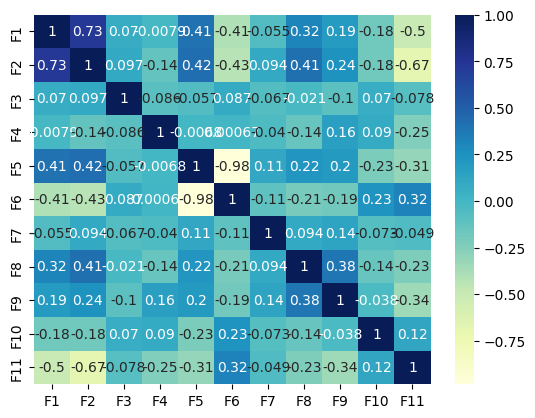

In [ ]:
# Compute correlation matrix
co_mtx = Dfr3.corr(numeric_only=True)

# Print correlation matrix
print(co_mtx)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()

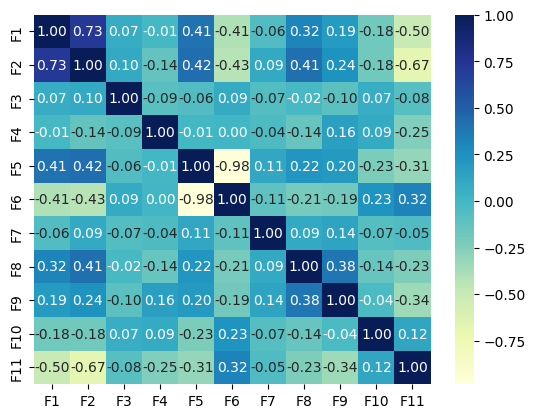

In [ ]:
co_mtx = Dfr3.corr(numeric_only=True)
# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True, fmt='.2f')

# Display heatmap
plt.savefig("Heatmap Phuket factors.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [ ]:
dff1 = pd.DataFrame(Dfr3)

# Add constant term for intercept
X = add_constant(dff1)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

   Feature        VIF
0    const  80.186041
1       F1   2.316785
2       F2   3.864115
3       F3   1.098544
4       F4   1.368932
5       F5  32.998124
6       F6  33.330503
7       F7   1.079636
8       F8   1.407569
9       F9   1.360778
10     F10   1.091774
11     F11   2.473336
